# RoBERTa on Cleaned Full Articles

This notebook loads the saved processed CSVs from Google Drive, uses only clean_text, and trains RoBERTa with full-article chunking.

Because RoBERTa can only read about 512 tokens at once, each article is split into multiple 512-token chunks. The model trains on chunks, then validation predictions are aggregated back to the article level by averaging chunk logits. The final accuracy and macro-F1 are article-level metrics.

## 1. Install Libraries

In [ ]:
!pip -q install datasets transformers accelerate scikit-learn pandas matplotlib seaborn torch

## 2. Imports and Configuration

In [ ]:
import os
import inspect
import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [ ]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

LABEL_NAMES = ["right", "right-center", "least-biased", "left-center", "left"]
ID_TO_LABEL = dict(enumerate(LABEL_NAMES))
LABEL_TO_ID = {name: i for i, name in ID_TO_LABEL.items()}

DRIVE_ROOT = "/content/chethas_full_roberta_drive"
PREPROCESSING_DIR = f"{DRIVE_ROOT}/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs"
OUTPUT_DIR = f"{DRIVE_ROOT}/MyDrive/cs4650_finalproj/roberta_clean_full_article_outputs"

MODEL_NAME = "roberta-base"
MAX_LEN = 512
CHUNK_BODY_LEN = MAX_LEN - 2

MAX_CHUNKS_PER_ARTICLE = None

NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3. Mount Google Drive


In [ ]:
import os
import shutil
from google.colab import drive

if os.path.exists(DRIVE_ROOT) and not os.path.ismount(DRIVE_ROOT):
    shutil.rmtree(DRIVE_ROOT)

drive.mount(DRIVE_ROOT)
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/chethas_full_roberta_drive


## 4. Load Processed Data




This expects the preprocessing notebook to have already saved train_processed.csv and val_processed.csv to Google Drive.

In [ ]:
train_path = os.path.join(PREPROCESSING_DIR, "train_processed.csv")
val_path = os.path.join(PREPROCESSING_DIR, "val_processed.csv")

print("Train path:", train_path)
print("Validation path:", val_path)

train_processed = pd.read_csv(train_path)
val_processed = pd.read_csv(val_path)

print("Train shape:", train_processed.shape)
print("Validation shape:", val_processed.shape)
train_processed.head()

Train path: /content/chethas_full_roberta_drive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/train_processed.csv
Validation path: /content/chethas_full_roberta_drive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/val_processed.csv
Train shape: (20000, 8)
Validation shape: (4000, 8)


,split,title,raw_text,clean_text,label,label_name,raw_word_count,clean_word_count
0,train,Presumed guilty,"Presumed guilty. <p>Not long ago, my wife Helm...",presumed guilty long ago wife helm one morning...,3,left-center,787,362
1,train,A Judge Just Sentenced the Millionaire Montana...,A Judge Just Sentenced the Millionaire Montana...,judge sentenced millionaire montana politician...,4,left,254,157
2,train,More bodies found in Mexican grave,More bodies found in Mexican grave. <p>..........,body found mexican grave mexico city number ex...,2,least-biased,193,95
3,train,Primary Campaigns Coming to the Finish Line,Primary Campaigns Coming to the Finish Line. <...,primary campaign coming finish line polling pl...,2,least-biased,447,277
4,train,Bush Poaches a Longtime Clinton Backer,Bush Poaches a Longtime Clinton Backer. <p>Lyn...,bush poaches longtime clinton backer lynne sla...,4,left,921,566


In [ ]:
required_cols = ["clean_text", "label", "label_name"]
missing = [col for col in required_cols if col not in train_processed.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

train_processed = train_processed.reset_index(drop=True).copy()
val_processed = val_processed.reset_index(drop=True).copy()
train_processed["article_id"] = np.arange(len(train_processed))
val_processed["article_id"] = np.arange(len(val_processed))

print("Train labels:")
print(train_processed["label_name"].value_counts().reindex(LABEL_NAMES))
print("\nValidation labels:")
print(val_processed["label_name"].value_counts().reindex(LABEL_NAMES))

Train labels:
label_name
right           4000
right-center    4000
least-biased    4000
left-center     4000
left            4000
Name: count, dtype: int64

Validation labels:
label_name
right           800
right-center    800
least-biased    800
left-center     800
left            800
Name: count, dtype: int64


## 5. Full-Article Chunk Tokenization

RoBERTa cannot take the entire article as one sequence if it exceeds 512 tokens. Instead, we tokenize the complete cleaned article without truncation, split its token IDs into 510-token pieces, then add RoBERTa special tokens to each chunk. Each chunk inherits the original article label.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def chunk_token_ids(token_ids, chunk_body_len=CHUNK_BODY_LEN, max_chunks=MAX_CHUNKS_PER_ARTICLE):
    chunks = [
        token_ids[i:i + chunk_body_len]
        for i in range(0, len(token_ids), chunk_body_len)
    ]

    if not chunks:
        chunks = [[]]

    if max_chunks is not None:
        chunks = chunks[:max_chunks]

    return chunks

def build_chunk_dataframe(df, text_col="clean_text", split_name="train"):
    rows = []

    for row in df.itertuples(index=False):
        text = "" if pd.isna(getattr(row, text_col)) else str(getattr(row, text_col))
        label = int(getattr(row, "label"))
        article_id = int(getattr(row, "article_id"))

        token_ids = tokenizer(
            text,
            add_special_tokens=False,
            truncation=False
        )["input_ids"]

        chunks = chunk_token_ids(token_ids)

        for chunk_id, chunk in enumerate(chunks):
            chunk = chunk[:CHUNK_BODY_LEN]

            input_ids = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
            attention_mask = [1] * len(input_ids)

            rows.append({
                "article_id": article_id,
                "chunk_id": chunk_id,
                "num_chunks": len(chunks),
                "input_ids": input_ids,
                "attention_mask": attention_mask,
                "label": label,
            })

    chunk_df = pd.DataFrame(rows)

    print(f"{split_name}: {len(df):,} articles -> {len(chunk_df):,} chunks")
    print(chunk_df["num_chunks"].describe())

    return chunk_df


## 6. Build Chunk Datasets

This is the slow preprocessing step for full articles. The generated chunk CSVs are saved to Drive so you can reload them instead of rebuilding every time.

In [ ]:
chunk_cache_suffix = "full" if MAX_CHUNKS_PER_ARTICLE is None else f"max{MAX_CHUNKS_PER_ARTICLE}"
train_chunks_path = os.path.join(OUTPUT_DIR, f"train_clean_chunks_{chunk_cache_suffix}.csv")
val_chunks_path = os.path.join(OUTPUT_DIR, f"val_clean_chunks_{chunk_cache_suffix}.csv")

if os.path.exists(train_chunks_path) and os.path.exists(val_chunks_path):
    print("Loading cached chunk CSVs from Drive...")
    train_chunks = pd.read_csv(train_chunks_path)
    val_chunks = pd.read_csv(val_chunks_path)
    train_chunks["input_ids"] = train_chunks["input_ids"].apply(json.loads)
    train_chunks["attention_mask"] = train_chunks["attention_mask"].apply(json.loads)
    val_chunks["input_ids"] = val_chunks["input_ids"].apply(json.loads)
    val_chunks["attention_mask"] = val_chunks["attention_mask"].apply(json.loads)
else:
    train_chunks = build_chunk_dataframe(train_processed, split_name="train")
    val_chunks = build_chunk_dataframe(val_processed, split_name="validation")

    train_chunks_to_save = train_chunks.copy()
    val_chunks_to_save = val_chunks.copy()
    train_chunks_to_save["input_ids"] = train_chunks_to_save["input_ids"].apply(json.dumps)
    train_chunks_to_save["attention_mask"] = train_chunks_to_save["attention_mask"].apply(json.dumps)
    val_chunks_to_save["input_ids"] = val_chunks_to_save["input_ids"].apply(json.dumps)
    val_chunks_to_save["attention_mask"] = val_chunks_to_save["attention_mask"].apply(json.dumps)
    train_chunks_to_save.to_csv(train_chunks_path, index=False)
    val_chunks_to_save.to_csv(val_chunks_path, index=False)

print(train_chunks_path)
print(val_chunks_path)
print(train_chunks.head())

Token indices sequence length is longer than the specified maximum sequence length for this model (690 > 512). Running this sequence through the model will result in indexing errors


train: 20,000 articles -> 27,483 chunks
count    27483.000000
mean         2.068588
std          2.988052
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         45.000000
Name: num_chunks, dtype: float64
validation: 4,000 articles -> 7,908 chunks
count    7908.000000
mean        3.934244
std         3.790815
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        28.000000
Name: num_chunks, dtype: float64
/content/chethas_full_roberta_drive/MyDrive/cs4650_finalproj/roberta_clean_full_article_outputs/train_clean_chunks_full.csv
/content/chethas_full_roberta_drive/MyDrive/cs4650_finalproj/roberta_clean_full_article_outputs/val_clean_chunks_full.csv
   article_id  chunk_id  num_chunks  \
0           0         0           1   
1           1         0           1   
2           2         0           1   
3           3         0           1   
4           4         0           2   

                          

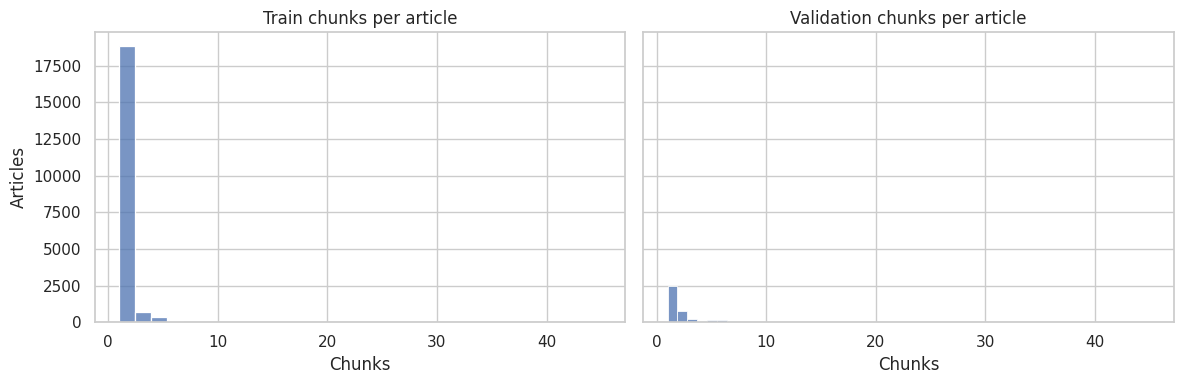

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
sns.histplot(train_chunks.drop_duplicates("article_id")["num_chunks"], bins=30, ax=axes[0])
axes[0].set_title("Train chunks per article")
axes[0].set_xlabel("Chunks")
axes[0].set_ylabel("Articles")

sns.histplot(val_chunks.drop_duplicates("article_id")["num_chunks"], bins=30, ax=axes[1])
axes[1].set_title("Validation chunks per article")
axes[1].set_xlabel("Chunks")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chunks_per_article.png"), dpi=200, bbox_inches="tight")
plt.show()

## 7. Convert to Hugging Face Datasets

In [ ]:
train_dataset = Dataset.from_pandas(train_chunks, preserve_index=False)
val_dataset = Dataset.from_pandas(val_chunks, preserve_index=False)

train_dataset = train_dataset.remove_columns([col for col in train_dataset.column_names if col not in ["input_ids", "attention_mask", "label"]])
val_dataset_for_trainer = val_dataset.remove_columns([col for col in val_dataset.column_names if col not in ["input_ids", "attention_mask", "label"]])

print(train_dataset)
print(val_dataset_for_trainer)

Dataset({
    features: ['input_ids', 'attention_mask', 'label'],
    num_rows: 27483
})
Dataset({
    features: ['input_ids', 'attention_mask', 'label'],
    num_rows: 7908
})


## 8. Model, Metrics, and Trainer Helpers

During training, validation metrics shown by Trainer are chunk-level. After training, we compute article-level metrics by averaging the logits for all chunks from the same article.

In [ ]:
def compute_chunk_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "chunk_accuracy": accuracy_score(labels, preds),
        "chunk_macro_f1": f1_score(labels, preds, average="macro"),
    }

def make_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABEL_NAMES),
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    )

def build_training_args(output_dir):
    sig = inspect.signature(TrainingArguments.__init__)
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "logging_steps": 50,
        "save_strategy": "epoch",
        "load_best_model_at_end": False,
        "optim": "adamw_torch",
        "report_to": "none",
        "seed": SEED,
    }

    if "eval_strategy" in sig.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    return TrainingArguments(**kwargs)

def make_trainer(model, training_args):
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": val_dataset_for_trainer,
        "data_collator": data_collator,
        "compute_metrics": compute_chunk_metrics,
    }

    trainer_sig = inspect.signature(Trainer.__init__)
    if "processing_class" in trainer_sig.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_sig.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    return Trainer(**trainer_kwargs)

## 9. Train RoBERTa on Clean Full-Article Chunks

This can take much longer than first-512 training because each article may create several chunks. The cell will resume from the latest checkpoint if it finds one in the experiment folder.

In [ ]:
experiment_name = "roberta-base_clean_full_article_chunks" if MAX_CHUNKS_PER_ARTICLE is None else f"roberta-base_clean_max{MAX_CHUNKS_PER_ARTICLE}_chunks"
experiment_dir = os.path.join(OUTPUT_DIR, experiment_name)
os.makedirs(experiment_dir, exist_ok=True)

model = make_model()
training_args = build_training_args(experiment_dir)
trainer = make_trainer(model, training_args)

last_checkpoint = None
if os.path.isdir(experiment_dir):
    checkpoints = [
        os.path.join(experiment_dir, d)
        for d in os.listdir(experiment_dir)
        if d.startswith("checkpoint-")
    ]
    if checkpoints:
        last_checkpoint = max(checkpoints, key=os.path.getmtime)
        print("Resuming from checkpoint:", last_checkpoint)

trainer.train(resume_from_checkpoint=last_checkpoint)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Chunk Accuracy,Chunk Macro F1
1,0.475018,2.539620,0.206373,0.205840


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Chunk Accuracy,Chunk Macro F1
1,0.475018,2.539620,0.206373,0.205840
2,0.459044,2.515253,0.273268,0.251873
3,0.416270,3.320929,0.251517,0.248943


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10308, training_loss=0.5382358086146168, metrics={'train_runtime': 1904.7856, 'train_samples_per_second': 43.285, 'train_steps_per_second': 5.412, 'total_flos': 2.142206163222732e+16, 'train_loss': 0.5382358086146168, 'epoch': 3.0})

## 10. Article-Level Evaluation

We average logits across all chunks for the same article, then choose the highest-scoring label. This gives one prediction per article.

In [ ]:
prediction_output = trainer.predict(val_dataset_for_trainer)
chunk_logits = prediction_output.predictions

val_chunk_meta = val_chunks[["article_id", "chunk_id", "label"]].copy().reset_index(drop=True)
logit_cols = [f"logit_{i}" for i in range(len(LABEL_NAMES))]
logit_df = pd.DataFrame(chunk_logits, columns=logit_cols)
chunk_preds_df = pd.concat([val_chunk_meta, logit_df], axis=1)

article_logits = chunk_preds_df.groupby("article_id")[logit_cols].mean()
article_pred_ids = article_logits.values.argmax(axis=1)

article_labels = val_processed.set_index("article_id").loc[article_logits.index, "label"].astype(int).values
article_acc = accuracy_score(article_labels, article_pred_ids)
article_macro_f1 = f1_score(article_labels, article_pred_ids, average="macro")
article_report = classification_report(article_labels, article_pred_ids, target_names=LABEL_NAMES, zero_division=0)
article_cm = confusion_matrix(article_labels, article_pred_ids, labels=list(range(len(LABEL_NAMES))))

print(f"Article-level Accuracy: {article_acc:.4f}")
print(f"Article-level Macro F1: {article_macro_f1:.4f}")
print(article_report)

Article-level Accuracy: 0.2915
Article-level Macro F1: 0.2798
              precision    recall  f1-score   support

       right       0.50      0.35      0.41       800
right-center       0.29      0.15      0.20       800
least-biased       0.23      0.08      0.12       800
 left-center       0.40      0.36      0.38       800
        left       0.20      0.51      0.29       800

    accuracy                           0.29      4000
   macro avg       0.32      0.29      0.28      4000
weighted avg       0.32      0.29      0.28      4000



## 11. Save Metrics, Predictions, Confusion Matrix, and Model

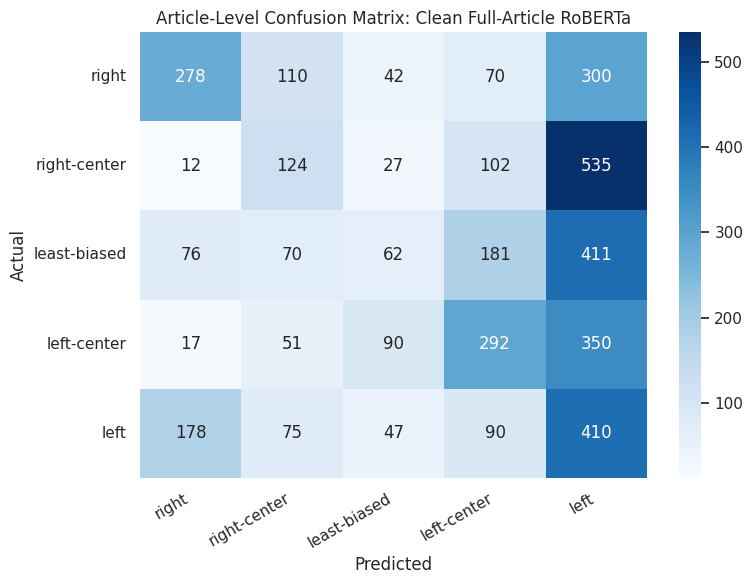

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved outputs to: /content/chethas_full_roberta_drive/MyDrive/cs4650_finalproj/roberta_clean_full_article_outputs/roberta-base_clean_full_article_chunks


In [ ]:
metrics = {
    "experiment": experiment_name,
    "model_name": MODEL_NAME,
    "text_col": "clean_text",
    "tokenization": "full_article_chunks",
    "max_chunks_per_article": MAX_CHUNKS_PER_ARTICLE,
    "article_accuracy": float(article_acc),
    "article_macro_f1": float(article_macro_f1),
    "train_articles": int(len(train_processed)),
    "validation_articles": int(len(val_processed)),
    "train_chunks": int(len(train_chunks)),
    "validation_chunks": int(len(val_chunks)),
}

with open(os.path.join(experiment_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

with open(os.path.join(experiment_dir, "classification_report_article_level.txt"), "w") as f:
    f.write(f"Experiment: {experiment_name}\n")
    f.write("Text column: clean_text\n")
    f.write("Tokenization: full article chunks\n")
    f.write(f"Article Macro-F1: {article_macro_f1:.4f} | Article Accuracy: {article_acc:.4f}\n\n")
    f.write(article_report)

preds_df = val_processed[["article_id", "title", "raw_text", "clean_text", "label", "label_name"]].copy()
preds_df = preds_df.set_index("article_id").loc[article_logits.index].reset_index()
preds_df["predicted"] = article_pred_ids
preds_df["predicted_label"] = [ID_TO_LABEL[p] for p in article_pred_ids]
preds_df.to_csv(os.path.join(experiment_dir, "article_predictions.csv"), index=False)

chunk_preds_df["chunk_pred"] = chunk_logits.argmax(axis=1)
chunk_preds_df["chunk_pred_label"] = [ID_TO_LABEL[p] for p in chunk_preds_df["chunk_pred"]]
chunk_preds_df.to_csv(os.path.join(experiment_dir, "chunk_predictions.csv"), index=False)

plt.figure(figsize=(8, 6))
sns.heatmap(article_cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Article-Level Confusion Matrix: Clean Full-Article RoBERTa")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(experiment_dir, "confusion_matrix_article_level.png"), dpi=200, bbox_inches="tight")
plt.show()

trainer.save_model(os.path.join(experiment_dir, "final_model"))
tokenizer.save_pretrained(os.path.join(experiment_dir, "final_model"))

print("Saved outputs to:", experiment_dir)